In [10]:
import numpy as np
from pathlib import Path
import json
import pandas as pd
import pyvista as pv
import matplotlib.pyplot as plt

from phd_helpers.experiments import (
    get_sensor_loc, parse_tekscan, F2P, build_sensor_mesh, project_sensor, project_sensor_new, project_sensor_complex, force_per_frame
)
from phd_helpers.AbaqusPostprocessing import inp2pv, get_field_path, get_field_df, add_field_to_mesh, get_history_path

# New experimental data from 20260611
- 1 mm/min testing
- Better calibration range (see moreCalibration.ipynb)
    - Compared high2, high1, mid2
- Masked the raw values (8, 4, 0 for high2, high1, mid2)

# Study3_35T4d5_Fsteps
 - Updated elastico and vero material properties with currest best known values
 - Using main_inpFsteps [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 150]
 - Cartilage friction = 0.0
   - wasn't sensitive and planning to do expriments with ptfe or lubricant
 - Experiments done with ptfe sheets either side of sensor
   - Calibrated with 10x10mm vero-elastico-ptfe blocks set up

# Thoughts
 - Tekscan data looks good but the pressure is still a lot more concentrated than in the simulations
 - I think it might be a problem with the simulations though
 - I think they might be artificially stiff due to using T4 elements 
    - So cartilage can't deform as much and pressure is more evenly distributed
 - I'll rerun with T10 to see what difference that makes
    - 1.5 layers of T10 elements slightly reduced the peak pressure... (this matches up with mesh independence results)

In [11]:
fea_path = Path('../../../../Computational/InpPipeline/outputs/initialFEAstuff/accuracy')
inp_file = list(fea_path.glob('study3_35T*/**/*.inp'))[0]
inp_file

PosixPath('../../../../Computational/InpPipeline/outputs/initialFEAstuff/accuracy/study3_35T4d5_Fsteps/inpFiles/14548R/inp/35T-neutral-00/35T-neutral-00.inp')

In [12]:
def get_step_ids(inp_file):
    history_files = list(inp_file.parent.glob('resultCSVs/history*.csv'))
    step_ids = np.sort(np.unique([int(x.with_suffix('').name.replace('history_step-', '')) for x in history_files]))
    return step_ids

def fea_mets_from_mesh(mesh):
    return {
        'CA': mesh.field_data['CA'][0],
        'P_max': mesh.field_data['P_max'][0],
        'P_avg': mesh.field_data['P_avg'][0],
        'loc_Pmax': mesh.field_data['loc_Pmax'],
    }

def find_boundary_cells(a):
    """
    input: NxM array of cells
    Returns: NxM (1, 0) array of non-zero cells that border a zero"""
    a = np.asarray(a)
    m = a > 0
    out = np.zeros(a.shape, dtype=bool)

    out[1:, :]  |= m[1:, :]  & (a[:-1, :] == 0)
    out[:-1, :] |= m[:-1, :] & (a[1:, :] == 0)
    out[:, 1:]  |= m[:, 1:]  & (a[:, :-1] == 0)
    out[:, :-1] |= m[:, :-1] & (a[:, 1:] == 0)

    return out

def compute_img_metrics(img, sensel_area=1.6129):

    CA = len(img[img>0]) * sensel_area
    # CA error - between 25% and 125% of the area of the boundary cells 
    # - plenty of cases that could exceed these limits but still reasonable limits I think...
    # - Given the nature of the contacting surfaces, it would be impossible for every boundary cell to be an edge case 
    # - so error bars based on those would give unreasonably wide range
    CA_e_low = find_boundary_cells(img).sum() * sensel_area * 0.75 # lower bound error bar for CA
    CA_e_high = find_boundary_cells(img).sum() * sensel_area * 0.25 # upper bound error bar for CA
    
    P_max = img.max()
    P_avg = img[img>0].mean()
    loc_Pmax = np.array(np.where(img==img.max())).ravel() # idx - (i, j)

    return {
        'CA': CA,
        'CA_e_low': CA_e_low,
        'CA_e_high': CA_e_high,
        'P_max': P_max,
        'P_avg': P_avg,
        'loc_Pmax': loc_Pmax
    }

def compute_CA_overlap(img_fea, img_tek):
    mask_fea = (img_fea > 0)
    mask_tek = (img_tek > 0)
    CA_mean = (mask_fea.sum() + mask_tek.sum()) / 2
    CA_overlap = (mask_fea & mask_tek).sum()

    return 100-(100 * (CA_mean - CA_overlap) / CA_mean)

def compute_Pavg(mesh):
    """Converts CPRESS to cell data and computes area weighted average pressure"""
    tet_surf = mesh.extract_cells_by_type(10).extract_surface(algorithm=None)
    P = tet_surf.point_data_to_cell_data().cell_data['CPRESS'] 
        # CPRESS comes as point data
        # this assigns to each elements CPRESS value, the average of the CPRESS of the 3 points of the element
        # Edge case: elements has point CPRESS = [0, 0, 1.5], element given CPRESS = 0.5, but entire area considered in contact for avg
        # This slightly overestimates area and therefore reduces average pressure
    A = tet_surf.compute_cell_sizes()["Area"]
    mask = P > 0

    return np.sum(P[mask] * A[mask]) / np.sum(A[mask])

# Load tekscan data

In [13]:
tek_frame_paths = Path('../../../../Experimental/notebooks/Experiments/TekscanCalibration/moreCalibration')
sens = 'high1'

tek_data = {int(path.name.split('-')[0]): np.loadtxt(path) for path in tek_frame_paths.glob(f'*{sens}.txt')}

# Load FEA data

In [14]:
Fs = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 150] # N
force_steps = get_step_ids(inp_file)[1:]
bone = 'tpm'

frame = -1 # final frame of each step
field_metrics = ["CPRESS", "U"]

csv_dir = inp_file.parent / 'resultCSVs' 

# get F
run_id = inp_file.with_suffix('').name.split('-')[-1]
param_path = fea_path / f'study2_35T4d5/params/loop_params/{run_id}.json'
with open(param_path, 'r') as f:
    F = json.load(f)['_loop']['max_force']

# get meshes
#meshes_orig = inp2pv(inp_file)


fea_data = {} # {F1: {'tpm':mesh1, 'mc1':mesh1}, ...} - each mesh contains all fea data
for step, F in zip(force_steps, Fs):
    #meshes = meshes_orig.copy()
    meshes = inp2pv(inp_file)
    for bone, mesh in meshes.items():
        instance = f"{bone.upper()}_INST"
        
        # Field data
        for metric in field_metrics:
            field_path = get_field_path(csv_dir, metric, step, frame, instance)
            field_df = get_field_df(field_path)
            add_field_to_mesh(mesh, field_df)

        # History data
        history_data = pd.read_csv(get_history_path(csv_dir, step))
        # F
        #RF_data = history_data[history_data['historyOutputKey']=='RF1']
        #RF = np.abs(RF_data['value'].iloc[frame])
        # A
        CAREA_data = history_data[history_data['historyOutputDescription']=='Total area in contact']
        CA = CAREA_data['value'].iloc[frame]

        mesh.field_data['RF'] = F
        mesh.field_data['CA'] = CA

        #P_avg = np.mean(mesh['CPRESS'][mesh['CPRESS']>0])
        #Summary data
        mesh.field_data['P_max'] = mesh['CPRESS'].max()
        mesh.field_data['P_avg'] = compute_Pavg(mesh)
        mesh.field_data['loc_Pmax'] = np.array(mesh.points[np.argmax(mesh['CPRESS'])])

    fea_data[F] = meshes

In [15]:
fea_grid_data = {}
for F in Fs:

    surf = fea_data[F][bone].extract_surface(algorithm=None)
    mesh = surf.extract_cells(surf[f'{bone}_CART_SURF']==1).extract_surface(algorithm=None)

    sensor_loc = get_sensor_loc(fea_data[F]['mc1'], guide_wall_z=10, sensor_offset_z=-2, sensor_size=13.97) # skinny guide ledge
    sensor = build_sensor_mesh(sensor_loc, normal=(1, 0, 0), ncells=11, size=13.97)
    
    fea_grid_new = project_sensor_new(
        mesh=mesh,
        sensor=sensor,
        sensor_vals=tek_data[F],
        data_loc="cells",
        downscale_fea=True,
        return_fea_grid=True,
        active_sensel_width=0.635,  # use your model units
        pressure_name="CPRESS",
    )
    
    
    fea_grid_data[F] = fea_grid_new

# Plot results

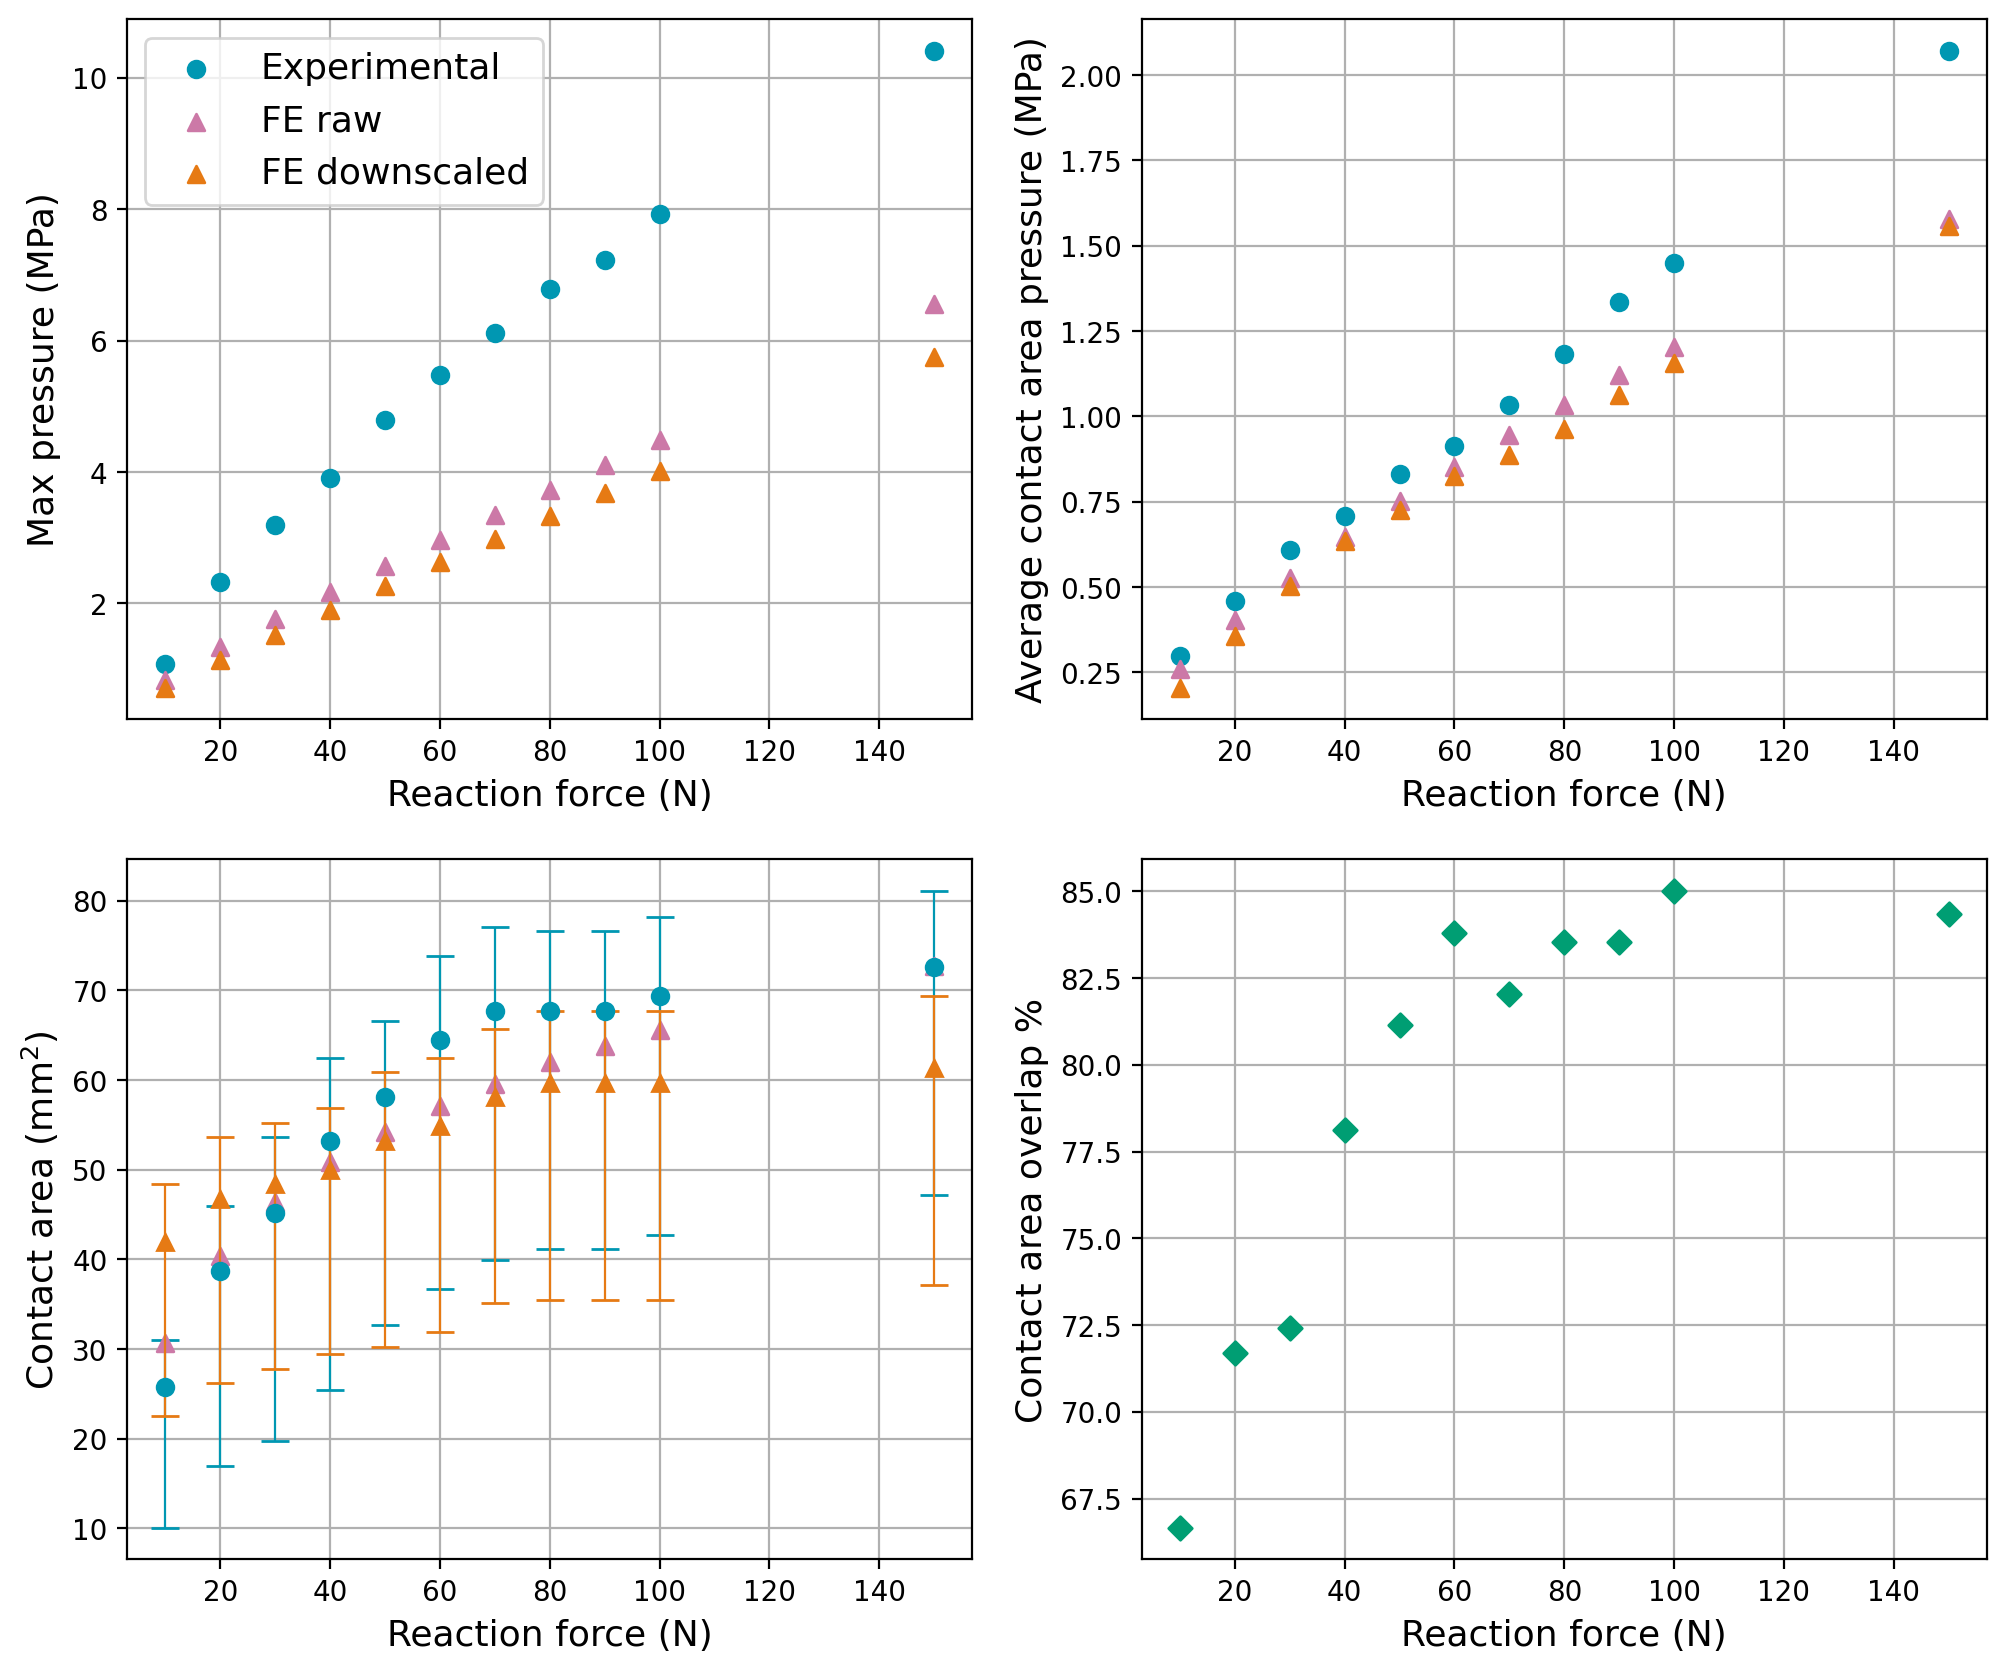

In [16]:
bone = 'tpm'

nrows, ncols = 2, 2
fig, ax = plt.subplots(nrows, ncols, figsize=(ncols*6, nrows*5), dpi=200)
ax = ax.flatten()


fs = 13
colors = {
    "tek": "#0097b2",
         #"#009e73"
    "FE downscaled": "#e67a14",
    'FE raw': "#cc79a7"
         #"#cc79a7"
         #"#bfb200"
    }
markers = {
    "tek": "o", 
    "FE downscaled": "^",
    'FE raw': "^"
}

for F in Fs:
    tek_mets = compute_img_metrics(tek_data[F])
    fea_mets = fea_mets_from_mesh(fea_data[F][bone])

    label_tek = 'Experimental' if F==10 else None
    label_fea = 'FE raw' if F==10 else None
    ax[0].scatter(F, tek_mets['P_max'], c=colors['tek'], marker=markers['tek'], label=label_tek, zorder=2)
    ax[1].scatter(F, tek_mets['P_avg'], c=colors['tek'], marker=markers['tek'], zorder=2)
    #ax[2].scatter(F, tek_mets['CA'], c=colors['tek'], marker=markers['tek'], zorder=2)
    ax[2].errorbar(F, tek_mets['CA'], yerr=[[tek_mets['CA_e_low']], [tek_mets['CA_e_high']]] , c=colors['tek'], marker=markers['tek'], capsize=5, elinewidth=0.8)

    ax[0].scatter(F, fea_mets['P_max'], c=colors['FE raw'], marker=markers['FE raw'], label=label_fea, zorder=2)
    ax[1].scatter(F, fea_mets['P_avg'], c=colors['FE raw'], marker=markers['FE raw'], zorder=2)
    ax[2].scatter(F, fea_mets['CA'], c=colors['FE raw'], marker=markers['FE raw'], zorder=2)

for F in Fs:
    fea_mets = compute_img_metrics(fea_grid_data[F])
    tek_mets = compute_img_metrics(tek_data[F])

    label_fea = 'FE downscaled' if F==10 else None
    ax[0].scatter(F, fea_mets['P_max'], c=colors['FE downscaled'], marker=markers['FE downscaled'], label=label_fea, zorder=2)
    ax[1].scatter(F, fea_mets['P_avg'], c=colors['FE downscaled'], marker=markers['FE downscaled'], zorder=2)
    #ax[2].scatter(F, fea_mets['CA'], c=colors['FE downscaled'], marker=markers['FE downscaled'], zorder=2)
    ax[2].errorbar(F, fea_mets['CA'], yerr=[[fea_mets['CA_e_low']],[fea_mets['CA_e_high']]],c=colors['FE downscaled'],marker=markers['FE downscaled'],capsize=5,elinewidth=0.8)


    ax[3].scatter(F, compute_CA_overlap(fea_grid_data[F], tek_data[F]), c="#009e73", marker="D", label=label_fea, zorder=2)



ax[0].set_ylabel('Max pressure (MPa)', fontsize=fs)
ax[1].set_ylabel('Average contact area pressure (MPa)', fontsize=fs)
ax[2].set_ylabel('Contact area (mm$^2$)', fontsize=fs)
ax[3].set_ylabel('Contact area overlap %', fontsize=fs)
for ax_i in ax:
    ax_i.set_xlabel('Reaction force (N)', fontsize=fs)
    ax_i.grid()
ax[0].legend(fontsize=fs)
#ax[3].legend(fontsize=fs)
plt.show()

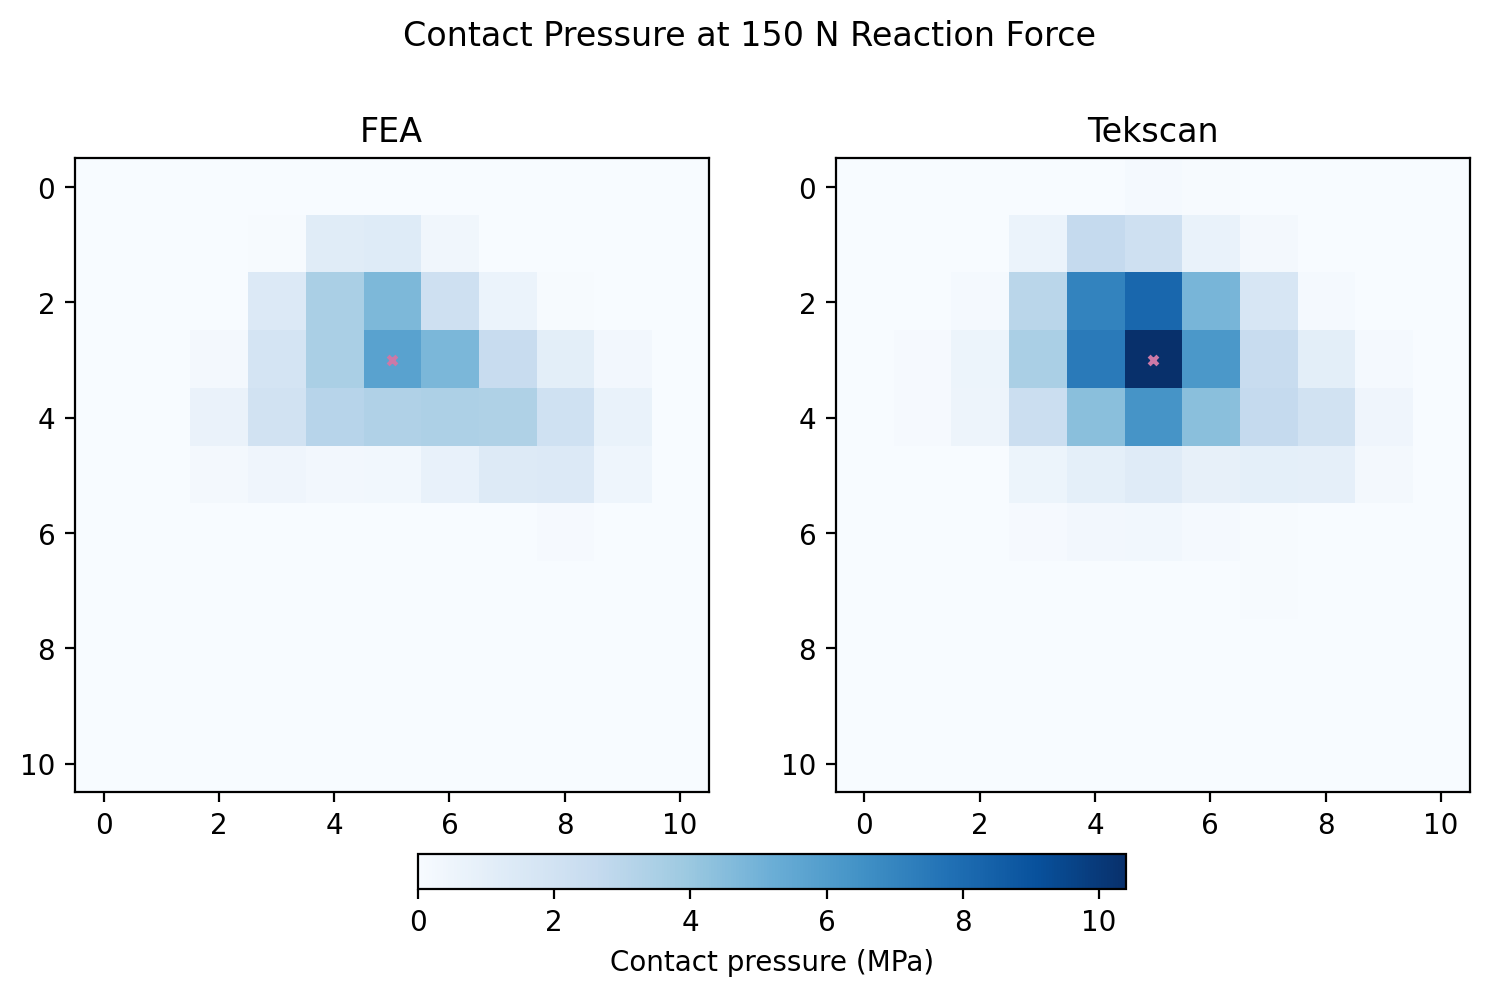

In [17]:
F = 150

nrows, ncols = 1, 2
fig, ax = plt.subplots(nrows, ncols, figsize=(4.5*ncols, 5*nrows), dpi=200)

P_fea, P_tek = fea_grid_data[F][::-1], tek_data[F][::-1]

press_min = np.min( [np.min(P_fea), np.min(P_tek)] )
press_max = np.max( [np.max(P_fea), np.max(P_tek)] )
clims = (press_min, press_max)

# imshows
im = ax[0].imshow(P_fea, vmin=clims[0], vmax=clims[1], cmap="Blues")
ax[1].imshow(P_tek, vmin=clims[0], vmax=clims[1], cmap='Blues')

# peak pressure loc
y, x = compute_img_metrics(P_fea)['loc_Pmax']
ax[0].scatter(x, y, color="#cc79a7", s=10, marker='x')
y, x = compute_img_metrics(P_tek)['loc_Pmax']
ax[1].scatter(x, y, color="#cc79a7", s=10, marker='x')

ax[0].set_title('FEA')
ax[1].set_title('Tekscan')
fig.suptitle(f'Contact Pressure at {F} N Reaction Force')

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.08, orientation='horizontal')
cbar.set_label('Contact pressure (MPa)')

plt.show()

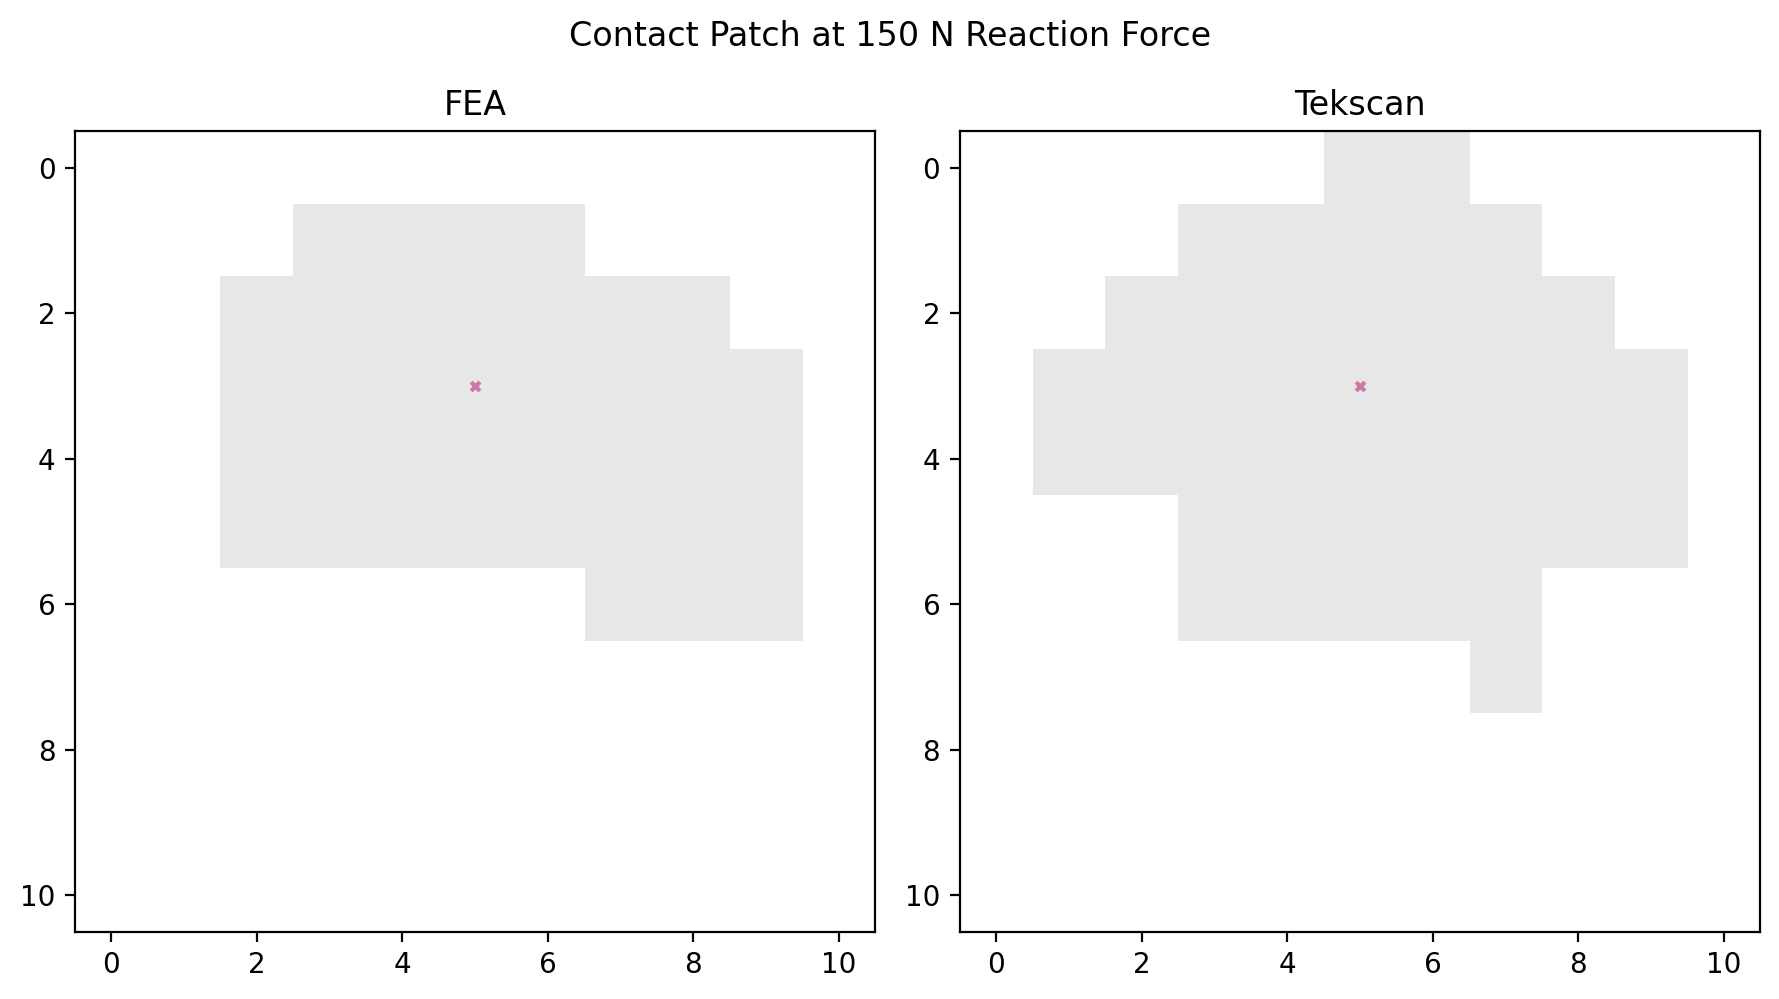

In [18]:
nrows, ncells = 1, 2
fig, ax = plt.subplots(nrows, ncols, figsize=(4.5*ncols, 5*nrows), dpi=200)

P_fea, P_tek = fea_grid_data[F][::-1], tek_data[F][::-1]

press_min = np.min( [np.min(P_fea), np.min(P_tek)] )
press_max = np.max( [np.max(P_fea), np.max(P_tek)] )
clims = (press_min, press_max)

# imshows
im = ax[0].imshow(P_fea>0, vmin=clims[0], vmax=clims[1], cmap='gray_r')
ax[1].imshow(P_tek>0, vmin=clims[0], vmax=clims[1], cmap='gray_r')

# peak pressure loc
ax[0].scatter(x, y, color="#cc79a7", s=10, marker='x')
ax[1].scatter(x, y, color="#cc79a7", s=10, marker='x')

ax[0].set_title('FEA')
ax[1].set_title('Tekscan')
fig.suptitle(f'Contact Patch at {F} N Reaction Force')

plt.tight_layout()
plt.show()

In [19]:
plot distance between p_max location

SyntaxError: invalid syntax (1111931383.py, line 1)

# Figs for presentation

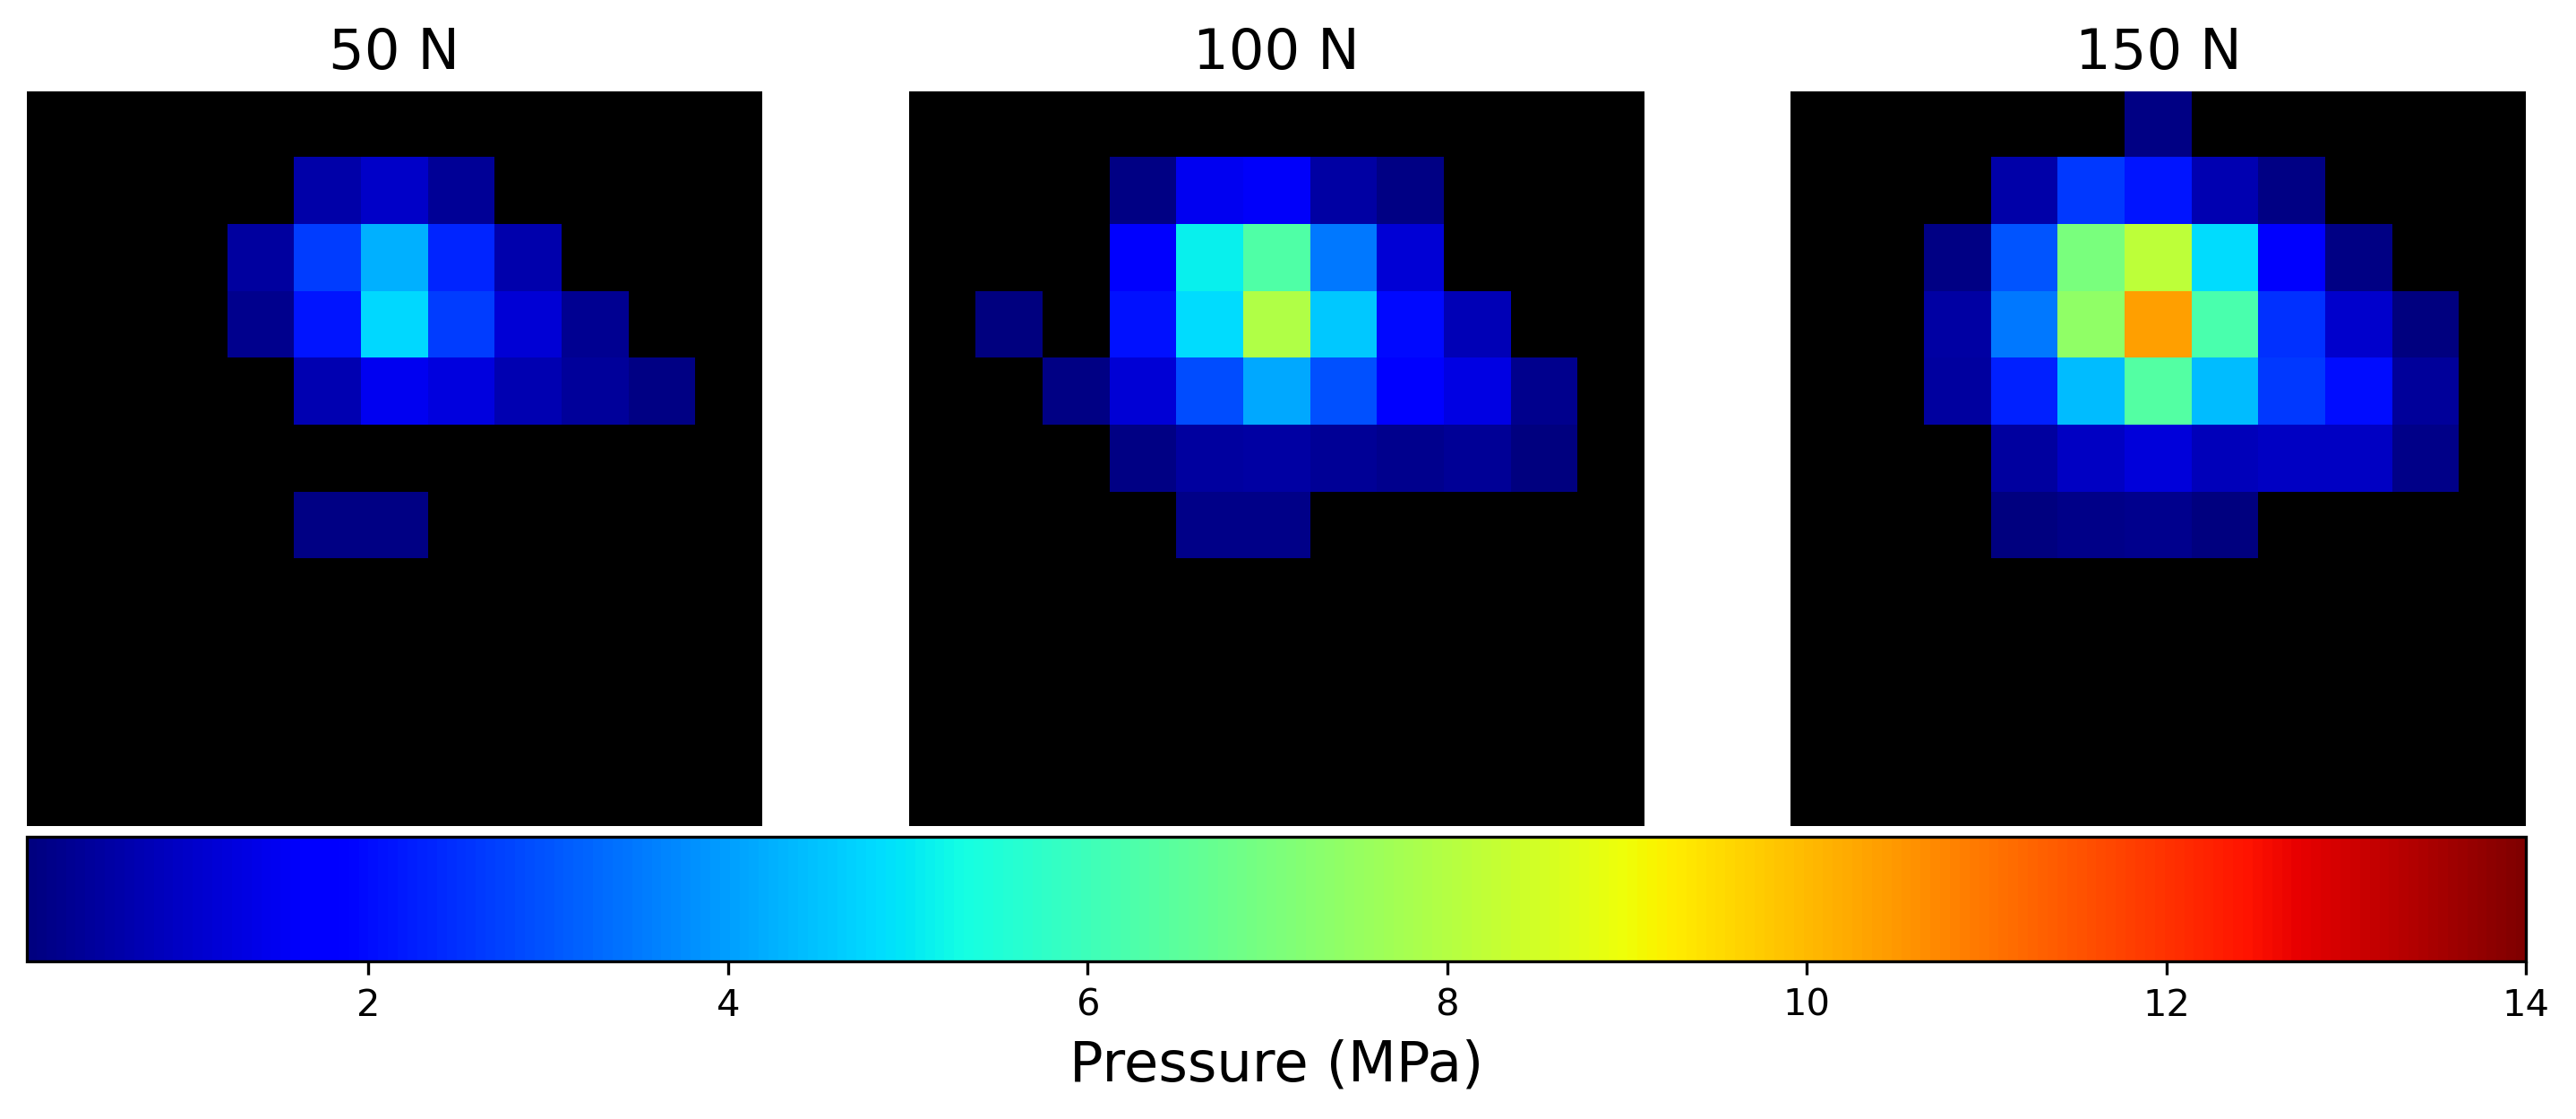

In [ ]:
fig, ax = plt.subplots(1,3, figsize=(12, 5), dpi=300)

Fs = [50, 100, 150]

#press_max = max([np.max(tek_data[F][::-1]) for F in Fs])
cmap = plt.cm.jet.copy()
cmap.set_under('black')

for F, a in zip(Fs, ax):
    im = a.imshow(tek_data[F][::-1], cmap=cmap, vmin=0.1, vmax=14)
    a.axis('off')
    a.set_title(f"{F} N", fontsize=15)


cbar = fig.colorbar(im, ax=ax, orientation='horizontal', pad=0.01) 
cbar.set_label('Pressure (MPa)', fontsize=15) 
plt.show()

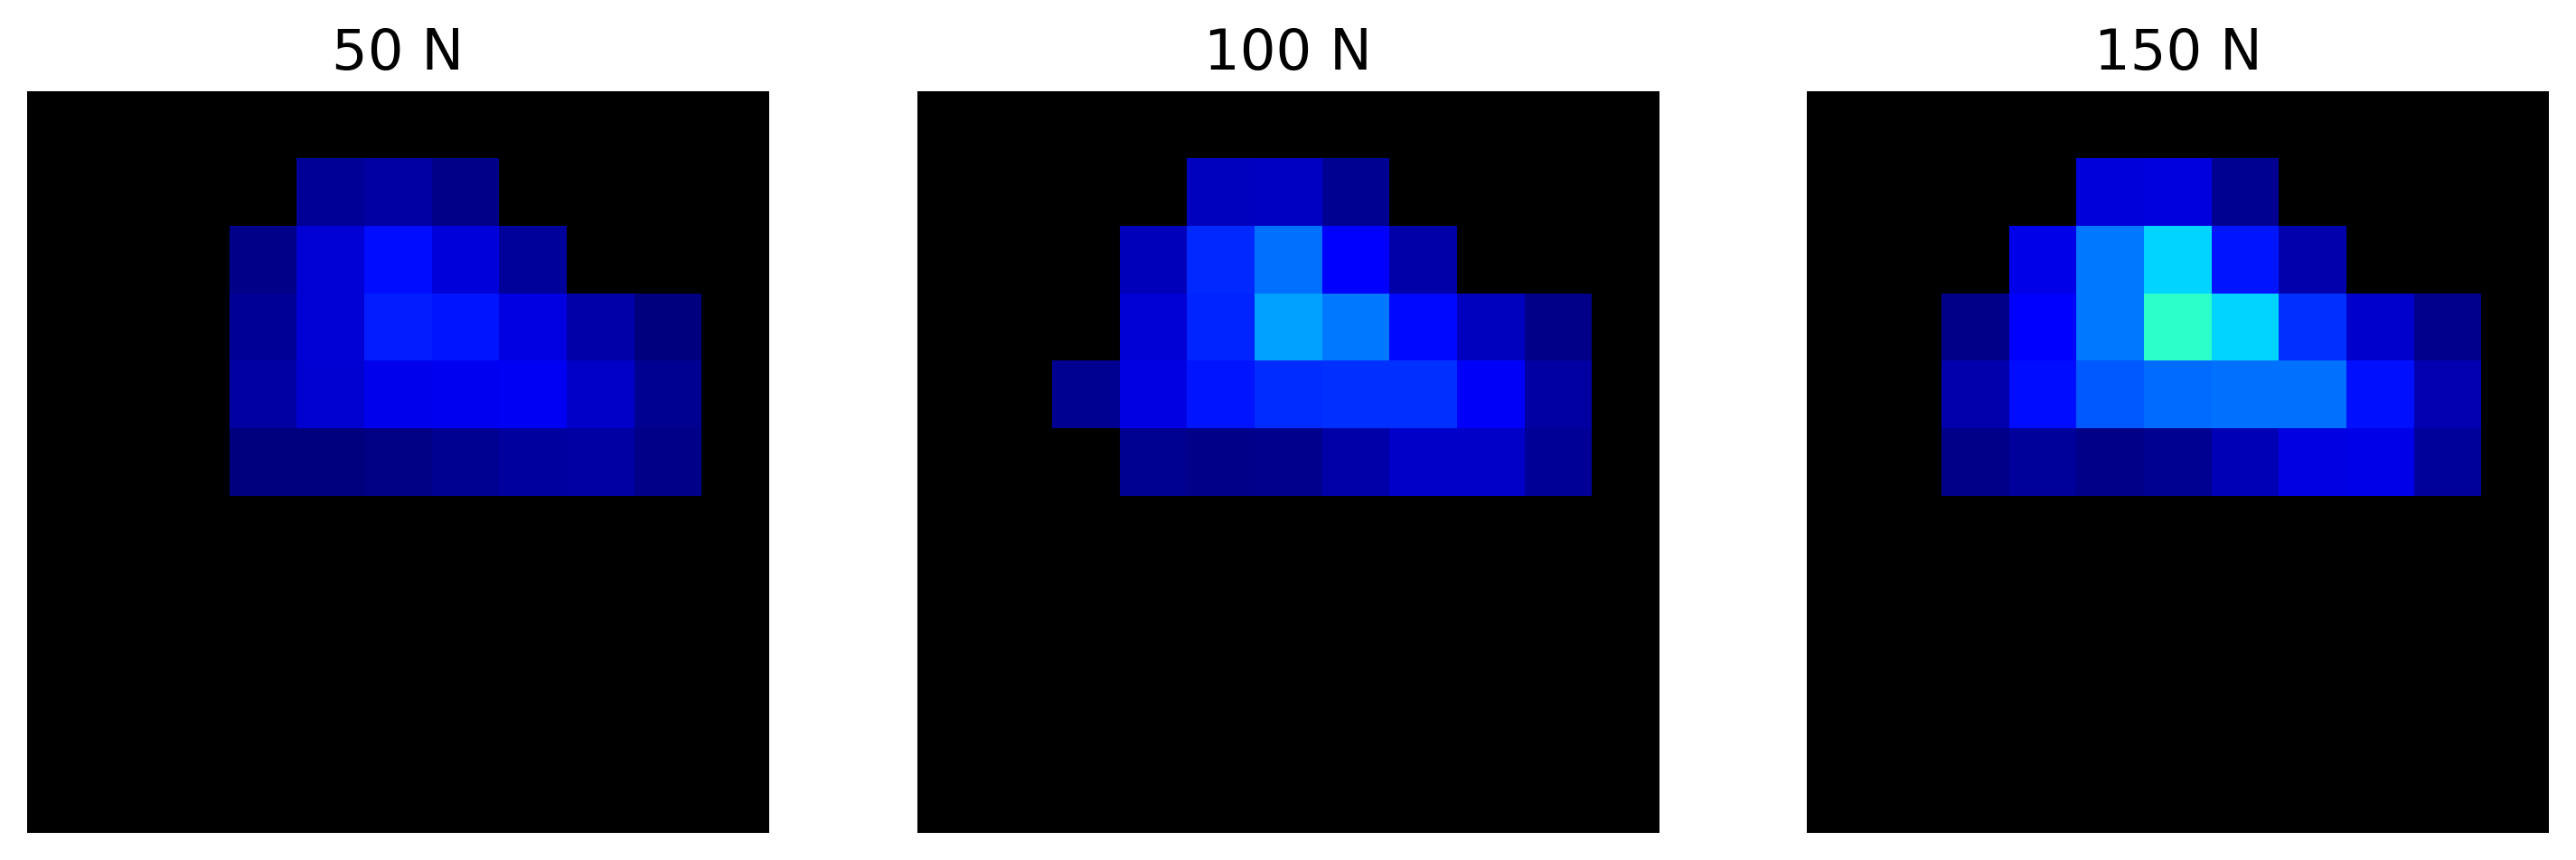

In [ ]:
fig, ax = plt.subplots(1,3, figsize=(12, 5), dpi=300)

Fs = [50, 100, 150]

#press_max = max([np.max(tek_data[F][::-1]) for F in Fs])
cmap = plt.cm.jet.copy()
cmap.set_under('black')

for F, a in zip(Fs, ax):
    im = a.imshow(fea_grid_data[F][::-1], cmap=cmap, vmin=0.1, vmax=14)
    a.axis('off')
    a.set_title(f"{F} N", fontsize=15)


#cbar = fig.colorbar(im, ax=ax, orientation='horizontal', pad=0.01) 
#cbar.set_label('Pressure (MPa)', fontsize=15) 
plt.show()

In [ ]:
F = 150

pl = pv.Plotter()
pl.add_mesh(fea_data[F]['tpm'], scalars='CPRESS', cmap=cmap, clim=[0.1, 14], show_scalar_bar=False, below_color='white')
pl.camera_position = pv.CameraPosition(position=(5.792239490884553, -0.4300173570490468, -0.8725899206361833),
               focal_point=(-25.33169641390228, 0.26322689204597527, 4.707462541332722),
               viewup=(0.17762593369397964, 0.07922819188193735, 0.9809036248737492))
pl.show()

Widget(value='<iframe src="http://localhost:59936/index.html?ui=P_0x326035af0_11&reconnect=auto" class="pyvist…

: 